In [ ]:
import os
from google.colab import userdata

os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "default"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "weekend_party"

Let's load and explore a dataset:

In [ ]:
from datasets import load_dataset
ds = load_dataset("cais/mmlu", "high_school_geography")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

high_school_geography/test-00000-of-0000(…):   0%|          | 0.00/28.2k [00:00<?, ?B/s]

high_school_geography/validation-00000-o(…):   0%|          | 0.00/6.16k [00:00<?, ?B/s]

high_school_geography/dev-00000-of-00001(…):   0%|          | 0.00/3.93k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/198 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/22 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

In [ ]:
ds_dict = ds["test"].take(100).to_dict()
print(ds_dict["question"][0])

The main factor preventing subsistence economies from advancing economically is the lack of


In [ ]:
print(ds_dict.keys())

dict_keys(['question', 'subject', 'choices', 'answer'])


In [ ]:
print(ds_dict["choices"][0])

['a currency.', 'a well-connected transportation infrastructure.', 'government activity.', 'a banking service.']


In [ ]:
ds_dict["answer"][0]

1

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
google_api_key = userdata.get('GOOGLE_API_KEY')
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview", google_api_key=google_api_key)

In [ ]:
from langchain_community.agent_toolkits.load_tools import load_tools
from langchain.agents import create_agent


research_tools = load_tools(
  tool_names=["ddg-search", "arxiv", "wikipedia"],
  llm=llm
)

system_prompt = (
    "You're a hard-working, curious and creative student. "
    "You're working on exam quesion. Think step by step."
    "Always provide an argumentation for your answer. "
    "Do not assume anything, use available tools to search "
    "for evidence and supporting statements."
)


In [ ]:
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langgraph.graph import MessagesState
from langchain.agents import AgentState


class ResearchState(AgentState):
  question: str
  options: str

research_agent = create_agent(model=llm, tools=research_tools, state_schema=ResearchState, system_prompt=system_prompt)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse, AgentState
from typing import Callable

instruction_template = "\nQUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n"

class InjectHumanPromptMiddleware(AgentMiddleware):
    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        content = instruction_template.format(
            question=request.state["question"],
            options=request.state["options"],
        )
        updated_messages = [HumanMessage(content=content)] + list(request.messages)
        return handler(request.override(messages=updated_messages))

research_agent = create_agent(
    model=llm,
    tools=research_tools,
    state_schema=ResearchState,
    middleware=[InjectHumanPromptMiddleware()]
)


In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse, AgentState
from typing import Callable

instruction_template_with_critique = (
    "You tried to answer the exam question and you get feedback from your "
    "professor. Work on improving your answer and incorporating the feedback. "
    "\nQUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n\n"
    "INITIAL ANSWER:\n{answer}\n\nFEEDBACK:\n{feedback}"

)

class ReflectionState(ResearchState):
  answer: str
  feedback: str

class InjectHumanPromptMiddlewareCritique(AgentMiddleware):
    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        content = instruction_template_with_critique.format(
            question=request.state["question"],
            options=request.state["options"],
        )
        updated_messages = [HumanMessage(content=content)] + list(request.messages)
        return handler(request.override(messages=updated_messages))

research_agent_with_critique = create_agent(
    model=llm,
    tools=research_tools,
    state_schema=ReflectionState,
    middleware=[InjectHumanPromptMiddlewareCritique()]
)


In [ ]:
from typing import Optional
from pydantic import BaseModel, Field


reflection_prompt = (
    "You are a university professor and you're supervising a student who is "
    "working on multiple-choice exam question. "
    "nQUESTION: {question}.\nANSWER OPTIONS:\n{options}\n."
    "STUDENT'S ANSWER:\n{answer}\n"
    "Reflect on the answer and provide a feedback whether the answer "
    "is right or wrong. If you think the student's answer is correct, rewrite the final answer "
    "in the `answer` field. "
    "Only provide critique if you think the answer is "
    "incorrect or there are reasoning flaws. Do not assume anything, "
    "evaluate only the reasoning the student provided and whether there is "
    "enough evidence for their answer."
)

class Response(BaseModel):
    """A final response to the user."""

    answer: Optional[str] = Field(
        description="The final answer to the original question. Always provide one if it's right and there's no critique.",
        default=None,
    )
    critique: Optional[str] = Field(
        description="A critique of the student's answer. If you think it is incorrect, provide an acitonable feedback",
        default=None,
    )


In [ ]:
from typing import Annotated, Literal, TypedDict
from langchain_core.runnables.config import RunnableConfig
from operator import add
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END


class ReflectionAgentState(TypedDict):
    question: str
    options: str
    answer: str
    steps: Annotated[int, add]
    response: Response


def _should_end(state: ReflectionAgentState, config: RunnableConfig) -> Literal["research", END]:
    max_reasoning_steps = config["configurable"].get("max_reasoning_steps", 10)
    if state.get("response") and state["response"].answer:
        return END
    if state.get("steps", 1) > max_reasoning_steps:
        return END
    return "research"

reflection_chain = PromptTemplate.from_template(reflection_prompt) | llm.with_structured_output(Response)

def _reflection_step(state: ReflectionAgentState):
    result = reflection_chain.invoke(state)
    return {"response": result, "steps": 1}


def _research_start(state: ReflectionAgentState):
  answer = research_agent.invoke(state)
  return {"answer": answer["messages"][-1].content}


def _research(state: ReflectionAgentState):
  agent_state = {
      "answer": state["answer"],
      "question": state["question"],
      "options": state["options"],
      "feedback": state["response"].critique
  }
  answer = research_agent_with_critique.invoke(agent_state)
  return {"answer": answer["messages"][-1].content}

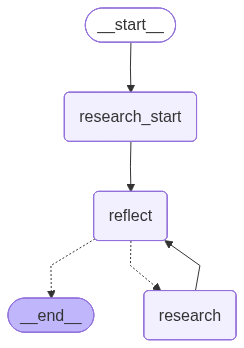

In [ ]:
builder = StateGraph(ReflectionAgentState)
builder.add_node("research_start", _research_start)
builder.add_node("research", _research)
builder.add_node("reflect", _reflection_step)

builder.add_edge(START, "research_start")
builder.add_edge("research_start", "reflect")
builder.add_edge("research", "reflect")
builder.add_conditional_edges("reflect", _should_end)
graph = builder.compile()


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Let's test it out:

In [ ]:
i = 22
question = ds_dict["question"][i]
options = "\n".join([f"{i}. {a}" for i, a in enumerate(ds_dict["choices"][i])])

async for _, event in graph.astream({"question": question, "options": options}, stream_mode=["updates"]):
  print(event)

{'research_start': {'answer': [{'type': 'text', 'text': 'The correct answer is **3. Christianity and Buddhism**.\n\nIn the study of geography and religion, a **universalizing religion** is one that attempts to be global, to appeal to all people regardless of location or culture, and actively seeks converts. **Christianity**, **Islam**, and **Buddhism** are the three major universalizing religions.\n\nIn contrast, **ethnic religions** (such as **Judaism** and **Hinduism**) typically appeal primarily to one group of people living in one place, or are tied to a specific culture or ethnicity, and do not actively seek converts.', 'extras': {'signature': 'EjQKMgG+Pvb7L3Z9CQV+au0zTw+z51x1cw0y9ihZ71T8btu2+JRZ/BGvNzbkq/FXmLLbZkUk'}}]}}
{'reflect': {'response': Response(answer='The correct answer is 3. Christianity and Buddhism. Both religions are classified as universalizing religions because they actively seek converts and aim to appeal to people globally, regardless of their cultural or ethni

In [ ]:
result = await graph.ainvoke({"question": question, "options": options})

In [ ]:
result

{'question': 'Which pair of religions are both universalizing religions?',
 'options': '0. Islam and Judaism\n1. Judaism and Buddhism\n2. Hinduism and Buddhism\n3. Christianity and Buddhism',
 'answer': [{'type': 'text',
   'text': 'The correct answer is **3. Christianity and Buddhism**.\n\nIn the study of geography and religion, **universalizing religions** are those that actively seek to appeal to all people, regardless of their cultural, ethnic, or geographic background. The three major universalizing religions are **Christianity, Islam, and Buddhism**.\n\nHere is why the other options are incorrect:\n*   **Judaism** and **Hinduism** are considered **ethnic religions**, which typically appeal primarily to one group of people living in one place.\n*   Based on these definitions:\n    *   0. Islam (universalizing) and Judaism (ethnic).\n    *   1. Judaism (ethnic) and Buddhism (universalizing).\n    *   2. Hinduism (ethnic) and Buddhism (universalizing).\n    *   3. **Christianity (un

# Communication through a shared list of messages

In [ ]:
research_tools = load_tools(
  tool_names=["ddg-search", "arxiv", "wikipedia"],
  llm=llm
)

system_prompt = (
    "You're a hard-working, curious and creative student. "
    "You're working on exam quesion. Think step by step."
    "Always provide an argumentation for your answer. "
    "Do not assume anything, use available tools to search "
    "for evidence and supporting statements."
)

research_agent = create_agent(model=llm, tools=research_tools, system_prompt=system_prompt)

reflection_prompt = (
    "You are a university professor and you're supervising a student who is "
    "working on multiple-choice exam question. "
    "Given the dialogue above, reflect on the answer provided and give a feedback "
    " if needed. If you think the final answer is correct, reply with "
    "an empty message. Only provide critique if you think the last answer might "
    "be incorrect or there are reasoning flaws. Do not assume anything, "
    "evaluate only the reasoning the student provided and whether there is "
    "enough evidence for their answer."
)

In [ ]:
from langchain_core.prompts import PromptTemplate
from langgraph.types import Command
from langchain_core.runnables import RunnableConfig


question_template = PromptTemplate.from_template(
    "QUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n\n"
)

def _ask_question(state):
  return {"messages": [("human", question_template.invoke(state).text)]}

def _give_feedback(state, config: RunnableConfig):
  messages = event["messages"] + [("human", reflection_prompt)]
  max_messages = config["configurable"].get("max_messages", 20)

  if len(messages) > max_messages:
    return Command(
      update={},
      goto=END
    )

  result = llm.invoke(messages)

  if result.content:
    return Command(
      update={"messages": [
          ("assistant", result.content),
           ("human", "Please, address the feedback above and give an answer.")]},
      goto="research"
  )
  return Command(
      update={},
      goto=END
  )

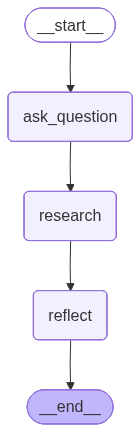

In [ ]:
class ReflectionAgentStateAlternative(MessagesState):
  question: str
  options: str


builder = StateGraph(ReflectionAgentStateAlternative)
builder.add_node("ask_question", _ask_question)
builder.add_node("research", research_agent)
builder.add_node("reflect", _give_feedback)

builder.add_edge(START, "ask_question")
builder.add_edge("ask_question", "research")
builder.add_edge("research", "reflect")
graph = builder.compile()


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
async for _, event in graph.astream({"question": question, "options": options}, stream_mode=["values"]):
  print(len(event["messages"]))

0
1
6
8
9
11
12
14
15


In [ ]:
for m in event["messages"]:
  print(type(m))

<class 'langchain_core.messages.human.HumanMessage'>
<class 'langchain_core.messages.ai.AIMessage'>
<class 'langchain_core.messages.tool.ToolMessage'>
<class 'langchain_core.messages.ai.AIMessage'>
<class 'langchain_core.messages.tool.ToolMessage'>
<class 'langchain_core.messages.ai.AIMessage'>
<class 'langchain_core.messages.ai.AIMessage'>
<class 'langchain_core.messages.human.HumanMessage'>
<class 'langchain_core.messages.ai.AIMessage'>
<class 'langchain_core.messages.ai.AIMessage'>
<class 'langchain_core.messages.human.HumanMessage'>
<class 'langchain_core.messages.ai.AIMessage'>
<class 'langchain_core.messages.ai.AIMessage'>
<class 'langchain_core.messages.human.HumanMessage'>
<class 'langchain_core.messages.ai.AIMessage'>


In [ ]:
for m in event["messages"]:
  m.pretty_print()

================================ Human Message =================================

QUESTION:
Which pair of religions are both universalizing religions?

ANSWER OPTIONS:
0. Islam and Judaism
1. Judaism and Buddhism
2. Hinduism and Buddhism
3. Christianity and Buddhism


================================== Ai Message ==================================

[]
Tool Calls:
  wikipedia (2a79f060-3e5b-496e-af1c-8f861c11d65e)
 Call ID: 2a79f060-3e5b-496e-af1c-8f861c11d65e
  Args:
    query: universalizing religion definition
================================= Tool Message =================================
Name: wikipedia

Page: Definition of religion
Summary: The definition of religion is a controversial and complicated subject in religious studies with scholars failing to agree on any one definition. Oxford Dictionaries defines religion as the belief in and/or worship of a superhuman controlling power, especially a personal God or gods. Others, such as Wilfred Cantwell Smith, have tried to correct 

# Installation

In [ ]:
!pip install --upgrade ddgs langsmith langchain-google-genai duckduckgo-search langchain-community langgraph arxiv wikipedia datasets huggingface_hub fsspec

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 359.1/359.1 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/